# Phase 6: Deep Reinforcement Learning — DQN & DDQN

## Motivation

Tabular methods (Phases 1-5) represent Q-values as a lookup table indexed by
discretized states. This works when the state space is small, but introduces a
fundamental trade-off: **coarser grids generalise better but lose precision;
finer grids retain precision but grow exponentially**.

With 20×20 bins (the optimal from Phase 2), each state is mapped to one of 400
cells. Two physically distinct states — say, position=−0.5, velocity=0.03 vs
position=−0.51, velocity=0.032 — collapse into the same cell and receive the
same Q-value estimate, even if the optimal action differs.

**Neural networks** solve this by approximating Q(s, a) as a continuous function
of the raw state vector [position, velocity]. No discretization needed. The
network generalises across similar states automatically via shared weights.

## Algorithms

### DQN — Deep Q-Network (Mnih et al., 2015)

Two key innovations over naïve neural Q-learning:

1. **Experience Replay**: Transitions (s, a, r, s', done) are stored in a
   circular buffer and sampled randomly during training. This breaks the temporal
   correlation between consecutive transitions that destabilises SGD updates.

2. **Target Network**: A separate "frozen" copy of the online network provides
   stable Q-value targets. Without it, both the predicted Q-values and the
   targets move simultaneously — the learning signal "chases itself" and diverges.
   The target network is updated periodically (hard copy or soft τ-blend).

**Update rule:**

    y = r + γ · max_a' Q_target(s', a')     if not terminal
    y = r                                    if terminal
    Loss = MSE(Q_online(s, a),  y)

### DDQN — Double DQN (van Hasselt et al., 2016)

Standard DQN uses the target network for both *action selection* and *action
evaluation* in the target: `max_a' Q_target(s', a')`. This causes systematic
**overestimation bias** — the max operation always selects the highest Q-value,
which is inflated by estimation noise.

DDQN decouples the two steps:

    a* = argmax_a' Q_online(s', a')       ← online net selects action
    y  = r + γ · Q_target(s', a*)         ← target net evaluates it

The online net's noisy argmax is corrected by the target net's more stable
evaluation, reducing overestimation and improving stability.

## Network Architecture

    Input:  [position, velocity]  (2 continuous values, not discretized)
       ↓  Linear(2 → 64) + ReLU
       ↓  Linear(64 → 64) + ReLU
       ↓  Linear(64 → 3)
    Output: [Q(s, Left), Q(s, Idle), Q(s, Right)]

## Experimental Design
- Environment: `MountainCar-v0`, min-steps reward
- State: raw continuous [position, velocity] — no binning
- Seeds: 5 per method
- Episodes: 5 000 (same budget as tabular for fair comparison)
- Tabular baseline: SARSA 20×20 bins (best method from Phase 4)
- Hyperparameter search: batch size ∈ {32, 64} × lr ∈ {0.0001, 0.001}


## Setup: Imports, Network, Replay Buffer, Agents


In [10]:
import sys, os, time, random
from collections import deque
from concurrent.futures import ThreadPoolExecutor, as_completed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root_path = os.path.abspath("..")
if root_path not in sys.path:
    sys.path.append(root_path)

import torch
import torch.nn as nn
import torch.optim as optim

from src.environment_utils import create_env, StateDiscretizer
from src.agents.tabular_agents import QLearning
from src.evaluation import train_agent, _extract_training_lists
from src.plotting import plot_policy_map

# Force CPU — QNetwork has ~4.5k parameters with batch_size=64.
# At this scale the host↔MPS/CUDA copy overhead per step exceeds the compute time.
# CPU is 10-20x faster here and allows genuine thread parallelism via PyTorch's C++ backend.
DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")


# ── Q-Network ─────────────────────────────────────────────────────────────────
class QNetwork(nn.Module):
    """2-layer MLP: state → Q-values for each discrete action."""
    def __init__(self, state_dim=2, n_actions=3, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden,    hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)


# ── Replay Buffer ─────────────────────────────────────────────────────────────
class ReplayBuffer:
    """Circular buffer storing (s, a, r, s', done) transitions."""
    def __init__(self, capacity=10_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, float(done)))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_, d = zip(*batch)
        return (np.array(s,  dtype=np.float32),
                np.array(a,  dtype=np.int64),
                np.array(r,  dtype=np.float32),
                np.array(s_, dtype=np.float32),
                np.array(d,  dtype=np.float32))

    def __len__(self):
        return len(self.buffer)

Device: cpu


In [11]:
class DQNAgent:
    """
    DQN or DDQN agent (controlled by `double` flag).

    DQN:  target selects and evaluates the next action.
    DDQN: online network selects; target network evaluates.
          This decoupling breaks the maximisation bias in the Bellman target.

    Target network updated via hard copy every `target_update_freq` steps.
    Gradient clipping at 1.0 for stability.
    """
    def __init__(self, lr=0.001, gamma=0.99,
                 epsilon_start=1.0, epsilon_decay=0.995, epsilon_min=0.05,
                 batch_size=64, buffer_capacity=10_000,
                 target_update_freq=100, double=False):
        self.gamma              = gamma
        self.epsilon            = epsilon_start
        self.epsilon_decay      = epsilon_decay
        self.epsilon_min        = epsilon_min
        self.batch_size         = batch_size
        self.target_update_freq = target_update_freq
        self.double             = double
        self.n_actions          = 3
        self._step              = 0

        self.online    = QNetwork().to(DEVICE)
        self.target    = QNetwork().to(DEVICE)
        self.target.load_state_dict(self.online.state_dict())
        self.target.eval()

        self.optimizer = optim.Adam(self.online.parameters(), lr=lr)
        self.buffer    = ReplayBuffer(buffer_capacity)
        self.loss_fn   = nn.MSELoss()

    def select_action(self, state):
        """ε-greedy action selection (used during training)."""
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            return int(self.online(s).argmax(dim=1).item())

    def act(self, state):
        """Greedy action selection — no exploration (used during evaluation)."""
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            return int(self.online(s).argmax(dim=1).item())

    def update(self):
        """One gradient step on a random mini-batch from the replay buffer."""
        if len(self.buffer) < self.batch_size:
            return None

        s, a, r, s_, d = self.buffer.sample(self.batch_size)
        s  = torch.tensor(s,  device=DEVICE)
        a  = torch.tensor(a,  device=DEVICE)
        r  = torch.tensor(r,  device=DEVICE)
        s_ = torch.tensor(s_, device=DEVICE)
        d  = torch.tensor(d,  device=DEVICE)

        q_pred = self.online(s).gather(1, a.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            if self.double:
                a_next = self.online(s_).argmax(dim=1)
                q_next = self.target(s_).gather(1, a_next.unsqueeze(1)).squeeze(1)
            else:
                q_next = self.target(s_).max(dim=1)[0]
            target = r + self.gamma * q_next * (1.0 - d)

        loss = self.loss_fn(q_pred, target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online.parameters(), 1.0)
        self.optimizer.step()

        self._step += 1
        if self._step % self.target_update_freq == 0:
            self.target.load_state_dict(self.online.state_dict())

        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


# ── DQN training loop ─────────────────────────────────────────────────────────
def train_dqn(agent, env, n_episodes, seed=0, warmup=1_000):
    """
    Standard DQN/DDQN training loop.
    Warmup: collect `warmup` transitions with random actions before any updates.
    Returns: (rewards, successes, steps_list, mean_losses) — one entry per episode.
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)

    rewards, successes, steps_list, losses = [], [], [], []

    for ep in range(n_episodes):
        state, _  = env.reset()
        total_r   = 0.0
        success   = False
        ep_losses = []

        while True:
            action = agent.select_action(state)
            next_s, r, term, trunc, _ = env.step(action)
            done = term or trunc

            agent.buffer.push(state, action, r, next_s, done)

            if len(agent.buffer) >= warmup:
                loss = agent.update()
                if loss is not None:
                    ep_losses.append(loss)

            total_r += r
            if term:
                success = True
            state = next_s
            if done:
                break

        agent.decay_epsilon()
        rewards.append(total_r)
        successes.append(int(success))
        steps_list.append(len(ep_losses) + (warmup if ep == 0 else 0))
        losses.append(float(np.mean(ep_losses)) if ep_losses else 0.0)

    return rewards, successes, steps_list, losses


print("QNetwork, ReplayBuffer, DQNAgent, train_dqn defined")
n_params = sum(p.numel() for p in QNetwork().parameters())
print(f"  Network parameters: {n_params:,}  (vs 20×20×3 = 1200 Q-table entries)")

QNetwork, ReplayBuffer, DQNAgent, train_dqn defined
  Network parameters: 4,547  (vs 20×20×3 = 1200 Q-table entries)


## Configuration


In [12]:
N_BINS     = 20        # tabular baseline grid (best from Phase 5)
N_EPISODES = 5_000     # same budget for all methods
N_SEEDS    = 5
WARMUP     = 1_000     # random transitions before first DQN gradient update

DQN_CFG = dict(
    lr                = 0.001,
    gamma             = 0.99,
    epsilon_start     = 1.0,
    epsilon_decay     = 0.995,
    epsilon_min       = 0.05,
    batch_size        = 64,
    buffer_capacity   = 10_000,
    target_update_freq= 100,
)

METHOD_COLORS = {
    "Q-Learning (20×20)": "#F18F01",
    "DQN":                "#2E86AB",
    "DDQN":               "#E84855",
}

print(f"N_BINS={N_BINS}  N_EPISODES={N_EPISODES}  N_SEEDS={N_SEEDS}  WARMUP={WARMUP}")
for k, v in DQN_CFG.items():
    print(f"  {k}={v}")

N_BINS=20  N_EPISODES=5000  N_SEEDS=5  WARMUP=1000
  lr=0.001
  gamma=0.99
  epsilon_start=1.0
  epsilon_decay=0.995
  epsilon_min=0.05
  batch_size=64
  buffer_capacity=10000
  target_update_freq=100


## Part 1 — Training: Q-Learning, DQN, DDQN

All three methods are trained on `MountainCar-v0` (discrete, min-steps) with the
same episode budget (5 000) and the same 5 seeds.

**Q-Learning (tabular baseline)** uses the 20×20 discretisation and the best
hyperparameters from Phase 5 — it outperformed SARSA there, so it is the correct
tabular reference here.

**DQN / DDQN** use the raw (position, velocity) state. The warmup period (1 000
random transitions) fills the replay buffer before the first gradient update.

**Parallel training**: All methods run on CPU (the QNetwork has ~4.5k parameters
with batch_size=64 — at this scale MPS/GPU transfer overhead exceeds the compute
time). A single `ThreadPoolExecutor` with `N_SEEDS × 3` workers submits all runs
simultaneously. PyTorch and NumPy both release the Python GIL during their C++
kernels, so all 9 threads compute genuinely in parallel.

In [13]:
# ── Per-method training helpers ───────────────────────────────────────────────
def run_ql(seed):
    """Train one Q-Learning agent and return (agent, rewards, successes, steps)."""
    env   = create_env("discrete", "min_steps", seed=seed)
    agent = QLearning(
        n_pos_bins=N_BINS,
        n_vel_bins=N_BINS,
        alpha=0.1,
        gamma=0.99,
        epsilon_decay=0.995,
        epsilon_min=0.05,
    )
    metrics, _ = train_agent(agent, env, n_episodes=N_EPISODES, seed=seed, verbose=False)
    rewards, successes, steps = _extract_training_lists(metrics)
    env.close()
    return agent, rewards, successes, steps


def run_dqn(seed, double=False):
    """Train one DQN or DDQN agent and return (agent, rewards, successes, steps, losses)."""
    env   = create_env("discrete", "min_steps", seed=seed)
    agent = DQNAgent(**DQN_CFG, double=double)
    rewards, successes, steps, losses = train_dqn(agent, env, N_EPISODES, seed, WARMUP)
    env.close()
    return agent, rewards, successes, steps, losses


print("Training helpers defined: run_ql, run_dqn")

Training helpers defined: run_ql, run_dqn


In [14]:
results = {m: {"rewards": [], "successes": [], "steps": [], "action_counts": []}
           for m in METHOD_COLORS}
results["DQN"]["losses"]  = []
results["DDQN"]["losses"] = []

# ── Parallel training: all seeds × all methods at once ────────────────────────
# All N_SEEDS*3 runs are submitted simultaneously. PyTorch and NumPy both release
# the GIL during their C++ kernels, so threads genuinely compute in parallel on CPU.
n_workers = N_SEEDS * 3
print(f"Launching {n_workers} training runs in parallel "
      f"({N_SEEDS} seeds × Q-Learning / DQN / DDQN)...")
t0_total = time.time()

raw = {}   # raw[seed][method_tag] = result tuple
with ThreadPoolExecutor(max_workers=n_workers) as pool:
    # Tag each future with (seed, method_tag) so we can route results on arrival
    future_map = {}
    for s in range(N_SEEDS):
        future_map[pool.submit(run_ql,  s)]        = (s, "ql")
        future_map[pool.submit(run_dqn, s, False)] = (s, "dqn")
        future_map[pool.submit(run_dqn, s, True)]  = (s, "ddqn")

    # Print a line as each run finishes — no waiting for the slowest
    for fut in as_completed(future_map):
        s, tag = future_map[fut]
        raw.setdefault(s, {})[tag] = fut.result()
        sr = float(np.mean(fut.result()[2][-100:]))   # index 2 = successes list
        print(f"  ✓ {tag.upper():5s} seed {s}  SR(last 100)={sr:.1%}", flush=True)

print(f"\nAll training done in {time.time()-t0_total:.0f}s\n")

# ── Per-seed summary & results collection ─────────────────────────────────────
for s in range(N_SEEDS):
    agent_ql,   r_ql,   s_ql,   st_ql             = raw[s]["ql"]
    agent_dqn,  r_dqn,  s_dqn,  st_dqn,  l_dqn   = raw[s]["dqn"]
    agent_ddqn, r_ddqn, s_ddqn, st_ddqn, l_ddqn   = raw[s]["ddqn"]

    print(f"Seed {s}  |  QL SR={np.mean(s_ql[-100:]):.1%}  "
          f"DQN SR={np.mean(s_dqn[-100:]):.1%}  "
          f"DDQN SR={np.mean(s_ddqn[-100:]):.1%}")

    # Greedy action distribution over 50 evaluation episodes (sequential — fast)
    for method, agent in [("Q-Learning (20×20)", agent_ql),
                           ("DQN",               agent_dqn),
                           ("DDQN",              agent_ddqn)]:
        ac    = np.zeros(3, dtype=np.int64)
        env_e = create_env("discrete", "min_steps", seed=s + 100)
        for _ in range(50):
            obs, _ = env_e.reset()
            done   = False
            while not done:
                if isinstance(agent, QLearning):
                    a = agent.act(obs, training=False)
                else:
                    a = agent.act(obs)
                ac[a] += 1
                obs, _, term, trunc, _ = env_e.step(a)
                done = term or trunc
        env_e.close()

        rw = {"Q-Learning (20×20)": r_ql,  "DQN": r_dqn,  "DDQN": r_ddqn}[method]
        sc = {"Q-Learning (20×20)": s_ql,  "DQN": s_dqn,  "DDQN": s_ddqn}[method]
        results[method]["rewards"].append(rw)
        results[method]["successes"].append(sc)
        results[method]["action_counts"].append(ac)

    results["DQN"]["losses"].append(l_dqn)
    results["DDQN"]["losses"].append(l_ddqn)

    if s == 0:
        best_agents = {
            "Q-Learning (20×20)": agent_ql,
            "DQN":                agent_dqn,
            "DDQN":               agent_ddqn,
        }

print("\nTraining complete")

Launching 15 training runs in parallel (5 seeds × Q-Learning / DQN / DDQN)...
  ✓ QL    seed 4  SR(last 100)=79.0%
  ✓ QL    seed 3  SR(last 100)=68.0%
  ✓ QL    seed 2  SR(last 100)=93.0%
  ✓ QL    seed 0  SR(last 100)=85.0%
  ✓ QL    seed 1  SR(last 100)=98.0%
  ✓ DQN   seed 1  SR(last 100)=99.0%
  ✓ DQN   seed 4  SR(last 100)=99.0%
  ✓ DQN   seed 0  SR(last 100)=93.0%
  ✓ DQN   seed 2  SR(last 100)=93.0%
  ✓ DQN   seed 3  SR(last 100)=100.0%
  ✓ DDQN  seed 3  SR(last 100)=97.0%
  ✓ DDQN  seed 0  SR(last 100)=96.0%
  ✓ DDQN  seed 1  SR(last 100)=100.0%
  ✓ DDQN  seed 4  SR(last 100)=99.0%
  ✓ DDQN  seed 2  SR(last 100)=99.0%

All training done in 10577s

Seed 0  |  QL SR=85.0%  DQN SR=93.0%  DDQN SR=96.0%
Seed 1  |  QL SR=98.0%  DQN SR=99.0%  DDQN SR=100.0%
Seed 2  |  QL SR=93.0%  DQN SR=93.0%  DDQN SR=99.0%
Seed 3  |  QL SR=68.0%  DQN SR=100.0%  DDQN SR=97.0%
Seed 4  |  QL SR=79.0%  DQN SR=99.0%  DDQN SR=99.0%

Training complete


### Learning Curves

Four panels: episode reward, success rate, steps per episode, and training loss
(DQN and DDQN only — tabular methods have no explicit loss function).

**What to look for:**
- Does DQN/DDQN learn faster or slower than the tabular baseline?
- How smooth are the deep RL curves vs. the tabular one? (replay buffer stabilises)
- Does DDQN reduce overestimation compared to DQN? (flatter loss, higher SR)

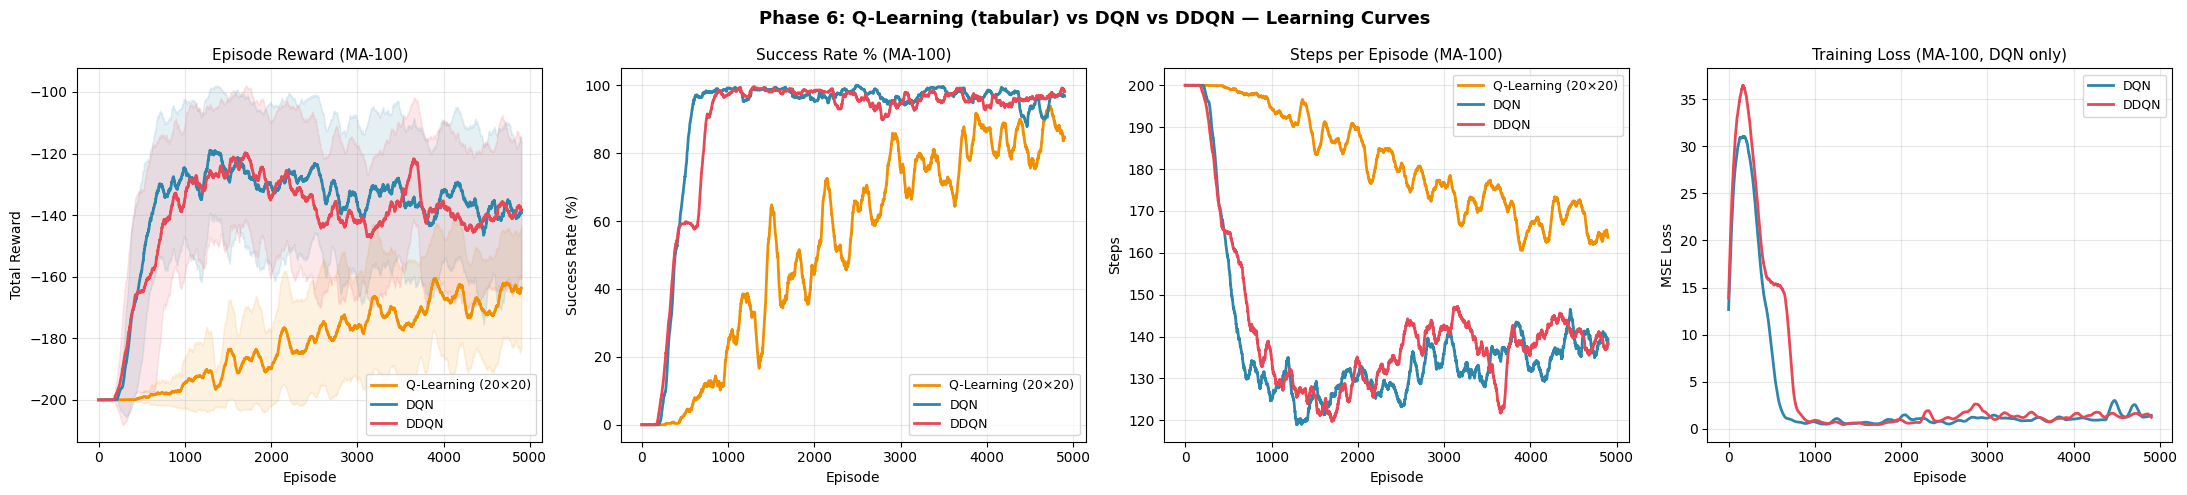

Saved: phase6_learning_curves.png


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
W = 100

def sm(x):
    return np.convolve(np.asarray(x, float), np.ones(W) / W, "valid")

for method, color in METHOD_COLORS.items():
    mean_r = np.mean(results[method]["rewards"],   axis=0)
    std_r  = np.std(results[method]["rewards"],    axis=0)
    mean_s = np.mean(results[method]["successes"], axis=0)

    ep = np.arange(len(sm(mean_r)))
    axes[0].plot(ep, sm(mean_r), color=color, label=method, linewidth=2)
    axes[0].fill_between(ep, sm(mean_r - std_r), sm(mean_r + std_r),
                         color=color, alpha=0.12)
    axes[1].plot(np.arange(len(sm(mean_s))), sm(mean_s) * 100,
                 color=color, label=method, linewidth=2)

    # Steps ≈ −reward for min-steps (reward = −1/step, no goal bonus when failed)
    approx_steps = -np.array(results[method]["rewards"])
    mean_st = np.mean(approx_steps, axis=0)
    axes[2].plot(np.arange(len(sm(mean_st))), sm(mean_st),
                 color=color, label=method, linewidth=2)

for method in ["DQN", "DDQN"]:
    color    = METHOD_COLORS[method]
    all_loss = np.array(results[method]["losses"])
    mean_l   = np.mean(all_loss, axis=0)
    axes[3].plot(np.arange(len(sm(mean_l))), sm(mean_l),
                 color=color, label=method, linewidth=2)

titles  = ["Episode Reward (MA-100)", "Success Rate % (MA-100)",
           "Steps per Episode (MA-100)", "Training Loss (MA-100, DQN only)"]
ylabels = ["Total Reward", "Success Rate (%)", "Steps", "MSE Loss"]
for ax, title, ylabel in zip(axes, titles, ylabels):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Episode")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
axes[1].set_ylim(-5, 105)

plt.suptitle("Phase 6: Q-Learning (tabular) vs DQN vs DDQN — Learning Curves",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("phase6_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase6_learning_curves.png")

### Performance Summary Table


In [16]:
rows = []
for method in METHOD_COLORS:
    succ_arr = np.array(results[method]["successes"])
    rew_arr  = np.array(results[method]["rewards"])
    ac_arr   = np.array(results[method]["action_counts"])

    sr  = succ_arr[:, -200:].mean(axis=1)
    rew = rew_arr[:,  -200:].mean(axis=1)
    tot = ac_arr.sum(axis=1)
    thr = (ac_arr[:, 0] + ac_arr[:, 2]) / tot   # left + right / total

    to_80 = []
    for sc in succ_arr:
        ma  = np.convolve(sc.astype(float), np.ones(100) / 100, "valid")
        idx = np.argmax(ma >= 0.80)
        to_80.append(int(idx + 100) if ma[idx] >= 0.80 else N_EPISODES)

    rows.append({
        "Method":       method,
        "Success Rate": f"{sr.mean()*100:.1f}% ± {sr.std()*100:.1f}%",
        "Avg Reward":   f"{rew.mean():.1f} ± {rew.std():.1f}",
        "Ep to 80% SR": f"{np.mean(to_80):.0f} ± {np.std(to_80):.0f}",
        "Thrust Rate":  f"{thr.mean()*100:.1f}%",
    })

df = pd.DataFrame(rows)
print("\nPHASE 6 — PERFORMANCE COMPARISON")
print("=" * 90)
print(df.to_string(index=False))
print("=" * 90)


PHASE 6 — PERFORMANCE COMPARISON
            Method Success Rate   Avg Reward Ep to 80% SR Thrust Rate
Q-Learning (20×20) 86.3% ± 6.2% -164.1 ± 5.7   2202 ± 234       79.6%
               DQN 96.8% ± 2.0% -138.7 ± 6.9     550 ± 85       91.2%
              DDQN 97.4% ± 1.2% -139.5 ± 7.0    608 ± 196       97.2%


### Per-Seed Success Rate

The per-seed breakdown reveals whether DQN and DDQN are more *robust* than
tabular Q-Learning, not just better on average. Neural function approximation
generalises across states, so a single successful trajectory updates Q-values
for many neighbouring states simultaneously. Tabular methods cannot do this.

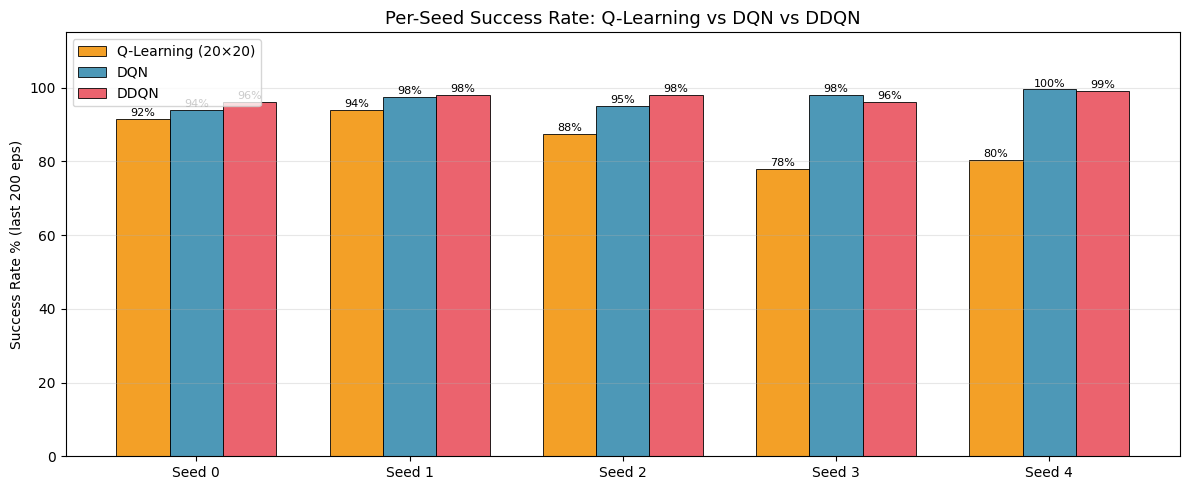

Saved: phase6_seed_variance.png


In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(N_SEEDS)
width   = 0.25
offsets = [-width, 0, width]

for i, (method, color) in enumerate(METHOD_COLORS.items()):
    per_seed = [np.mean(s[-200:]) * 100 for s in results[method]["successes"]]
    bars = ax.bar(x + offsets[i], per_seed, width=width,
                  color=color, alpha=0.85, edgecolor="black", linewidth=0.7, label=method)
    for bar, val in zip(bars, per_seed):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f"{val:.0f}%", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f"Seed {i}" for i in range(N_SEEDS)])
ax.set_ylabel("Success Rate % (last 200 eps)")
ax.set_title("Per-Seed Success Rate: Q-Learning vs DQN vs DDQN", fontsize=13)
ax.set_ylim(0, 115)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("phase6_seed_variance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase6_seed_variance.png")

### Q-Value Landscape: Tabular vs Neural Network

We query each model on a 20×20 grid of (position, velocity) states and plot:
1. `max_a Q(s, a)` — the learned value function
2. `argmax_a Q(s, a)` — the greedy policy

For Q-Learning this is the Q-table directly.
For DQN/DDQN the grid points are passed through the neural network.

**What to look for**: A well-converged agent shows a clear value gradient — high
values near the goal (position ≈ 0.6, positive velocity), low values far from it.
The neural network surface should be *smoother* because the network interpolates
between training states; the tabular surface has independent cell values.

The policy map should show the characteristic swing-up pattern:
Push Left when moving left (build leftward momentum), Push Right when moving right.

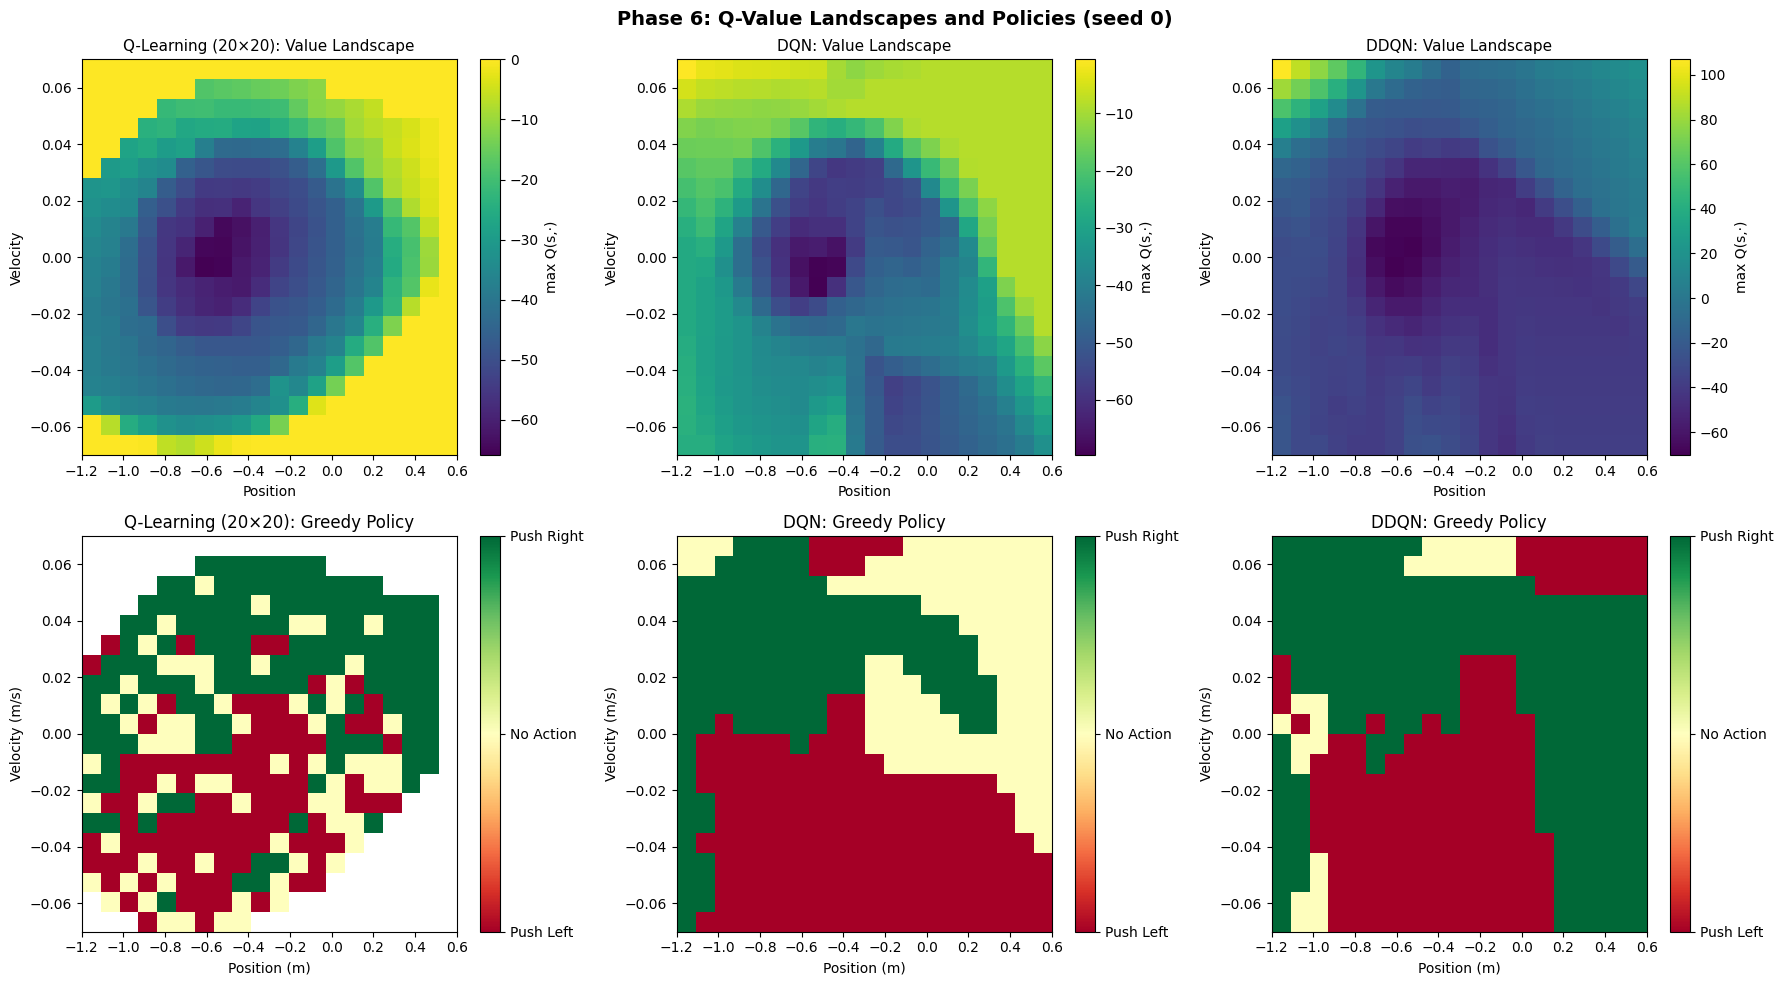

Saved: phase6_qvalue_landscapes.png

PHASE 6 COMPLETE
Saved: phase6_learning_curves.png
       phase6_seed_variance.png
       phase6_qvalue_landscapes.png


In [18]:
def nn_qvalues(agent, n_pos=20, n_vel=20):
    """Evaluate DQN/DDQN on a (pos, vel) grid. Returns array (n_pos, n_vel, 3)."""
    pos_vals = np.linspace(-1.2, 0.6, n_pos)
    vel_vals = np.linspace(-0.07, 0.07, n_vel)
    q_grid   = np.zeros((n_pos, n_vel, 3))
    agent.online.eval()
    with torch.no_grad():
        for i, pos in enumerate(pos_vals):
            for j, vel in enumerate(vel_vals):
                s = torch.tensor([[pos, vel]], dtype=torch.float32, device=DEVICE)
                q_grid[i, j] = agent.online(s).cpu().numpy()[0]
    agent.online.train()
    return q_grid


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (method, agent) in enumerate(best_agents.items()):
    if isinstance(agent, QLearning):
        q    = agent.Q                         # shape (20, 20, 3)
        disc = StateDiscretizer(N_BINS, N_BINS)
        mask = True
    else:
        q    = nn_qvalues(agent, n_pos=20, n_vel=20)
        disc = StateDiscretizer(20, 20)
        mask = False

    # Value landscape: max Q over actions
    max_q = np.max(q, axis=2)
    im = axes[0, col].imshow(max_q.T, origin="lower", aspect="auto",
                              extent=[-1.2, 0.6, -0.07, 0.07], cmap="viridis")
    plt.colorbar(im, ax=axes[0, col], label="max Q(s,·)")
    axes[0, col].set_title(f"{method}: Value Landscape", fontsize=11)
    axes[0, col].set_xlabel("Position")
    axes[0, col].set_ylabel("Velocity")

    # Policy map: argmax action per state
    plot_policy_map(
        q, disc,
        visit_counts=getattr(agent, "visit_counts", None),
        mask_unvisited=mask,
        title=f"{method}: Greedy Policy",
        ax=axes[1, col],
    )

plt.suptitle("Phase 6: Q-Value Landscapes and Policies (seed 0)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("phase6_qvalue_landscapes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase6_qvalue_landscapes.png")

# [CODE]
print("\n" + "="*60)
print("PHASE 6 COMPLETE")
print("="*60)
print("Saved: phase6_learning_curves.png")
print("       phase6_seed_variance.png")
print("       phase6_qvalue_landscapes.png")

### Greedy Trajectories in Phase Space

Each line is one greedy episode plotted in (position, velocity) space using the
best seed agent. The swing-up pattern is visible as the oscillating path before the
agent crests the hill: the policy repeatedly builds momentum by pushing in the
direction of current velocity.

Green triangle = start state. Red star = end state.
Solid lines = successful episodes (reached goal). Dashed = truncated.

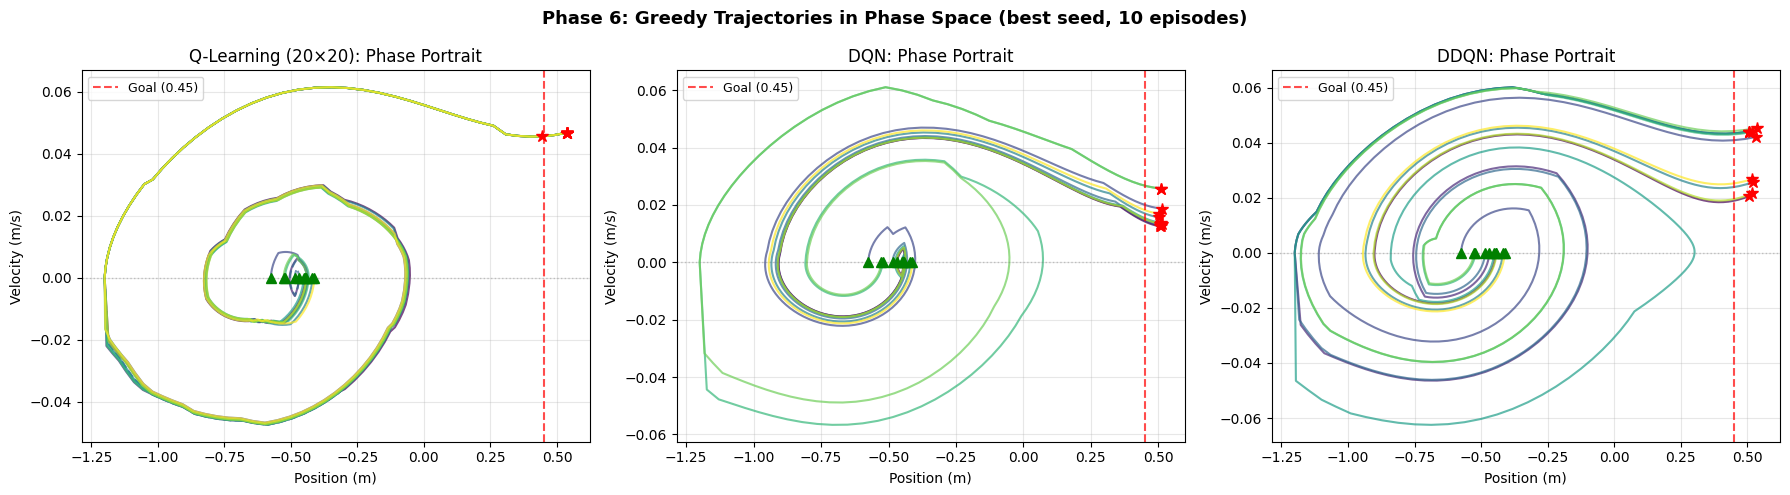

Saved: phase6_trajectories.png


In [20]:
def collect_trajectories(agent, n_episodes=10, seed=42):
    env = create_env("discrete", "min_steps", seed=seed)
    trajs = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        pos, vel = [obs[0]], [obs[1]]
        done = False
        while not done:
            a = agent.act(obs, training=False) if isinstance(agent, QLearning) else agent.act(obs)
            obs, _, term, trunc, _ = env.step(a)
            pos.append(obs[0]); vel.append(obs[1])
            done = term or trunc
        trajs.append((np.array(pos), np.array(vel), bool(term)))
    env.close()
    return trajs


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for col, method in enumerate(["Q-Learning (20×20)", "DQN", "DDQN"]):
    ax = axes[col]
    trajs = collect_trajectories(best_agents[method], n_episodes=10, seed=42)
    colors = plt.cm.viridis(np.linspace(0, 1, len(trajs)))
    for (pos, vel, success), c in zip(trajs, colors):
        ax.plot(pos, vel, color=c, alpha=0.7, lw=1.5, linestyle="-" if success else "--")
        ax.plot(pos[0],  vel[0],  "g^", ms=7, zorder=5)
        ax.plot(pos[-1], vel[-1], "r*", ms=9, zorder=5)
    ax.axvline(0.45, color="red", ls="--", lw=1.5, alpha=0.7, label="Goal (0.45)")
    ax.axhline(0,    color="gray", ls=":",  lw=1,   alpha=0.4)
    ax.set_xlabel("Position (m)"); ax.set_ylabel("Velocity (m/s)")
    ax.set_title(f"{method}: Phase Portrait")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle("Phase 6: Greedy Trajectories in Phase Space (best seed, 10 episodes)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("phase6_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase6_trajectories.png")

### Action Distribution

Fraction of greedy actions (push left / no-op / push right) over 50 evaluation
episodes, averaged across seeds. An effective policy strongly favours left and right
pushes to build momentum; few or no no-ops means the agent never wastes steps.

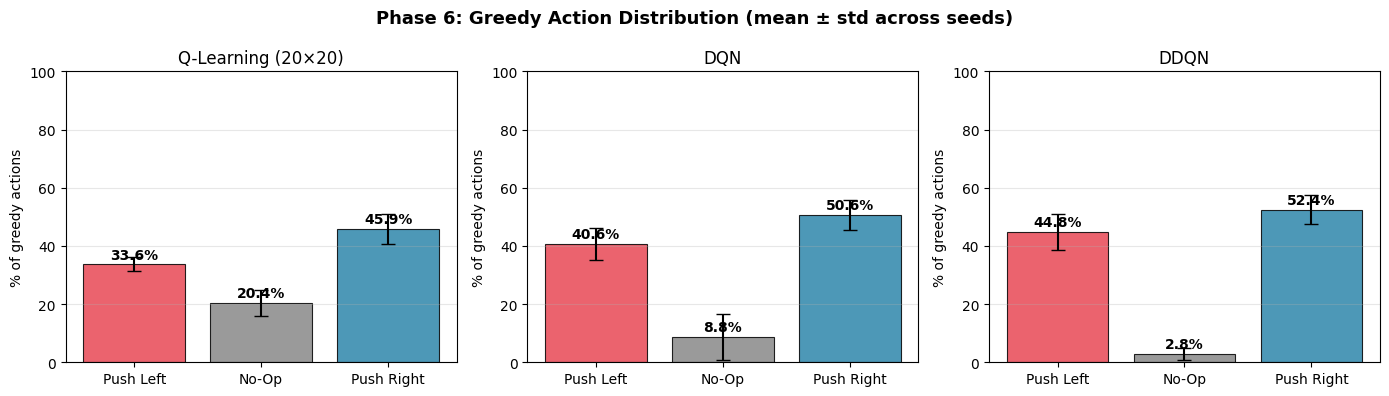

Saved: phase6_action_dist.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
action_labels  = ["Push Left", "No-Op", "Push Right"]
action_colors_ = ["#E84855", "#888888", "#2E86AB"]

for col, method in enumerate(["Q-Learning (20×20)", "DQN", "DDQN"]):
    ax = axes[col]
    ac_all = np.array(results[method]["action_counts"])       # (N_SEEDS, 3)
    fracs  = ac_all / ac_all.sum(axis=1, keepdims=True) * 100  # percentages per seed
    mean_f, std_f = fracs.mean(axis=0), fracs.std(axis=0)

    bars = ax.bar(action_labels, mean_f, color=action_colors_, alpha=0.85,
                  edgecolor="black", lw=0.8, yerr=std_f, capsize=5)
    for bar, v in zip(bars, mean_f):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")
    ax.set_title(method); ax.set_ylabel("% of greedy actions")
    ax.set_ylim(0, 100); ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Phase 6: Greedy Action Distribution (mean ± std across seeds)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("phase6_action_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase6_action_dist.png")

### Convergence Speed

How many episodes does each method need to first sustain a rolling success rate
above 50%, 80%, and 95% (measured over the most recent 100 episodes)?
A faster-converging method can reach good performance with less experience.

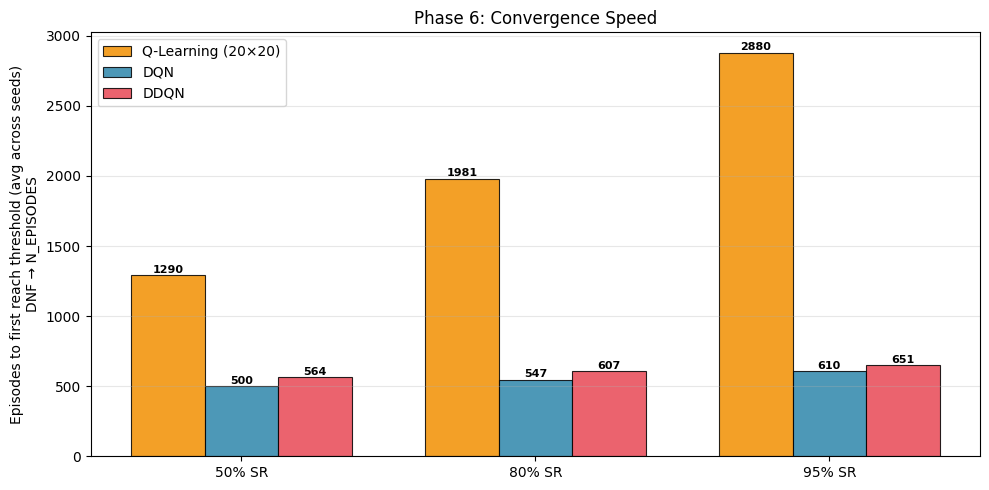

Saved: phase6_convergence.png


In [25]:
def episodes_to_threshold(successes, threshold=0.8, window=100):
    arr = np.array(successes, dtype=float)
    for i in range(window, len(arr)):
        if arr[i - window:i].mean() >= threshold:
            return i
    return None   # never reached


thresholds   = [0.5, 0.8, 0.95]
method_list  = ["Q-Learning (20×20)", "DQN", "DDQN"]
colors_list  = [METHOD_COLORS[m] for m in method_list]

fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(thresholds)), 0.25

for i, (method, color) in enumerate(zip(method_list, colors_list)):
    vals = []
    for thr in thresholds:
        ep_list = [episodes_to_threshold(s, thr) for s in results[method]["successes"]]
        ep_list = [e if e is not None else N_EPISODES for e in ep_list]
        vals.append(float(np.mean(ep_list)))
    bars = ax.bar(x + (i - 1) * w, vals, w, color=color, alpha=0.85,
                  edgecolor="black", lw=0.8, label=method)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
                f"{int(v)}", ha="center", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([f"{int(t*100)}% SR" for t in thresholds])
ax.set_ylabel("Episodes to first reach threshold (avg across seeds)\nDNF → N_EPISODES")
ax.set_title("Phase 6: Convergence Speed")
ax.legend(); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("phase6_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase6_convergence.png")

### DQN vs DDQN: Training Loss Detail

DDQN decouples action *selection* (online network) from action *evaluation* (target network),
breaking the maximisation bias in the Bellman target. This should produce lower and more
stable TD-error over training. Per-seed curves (faint) + cross-seed mean (black).

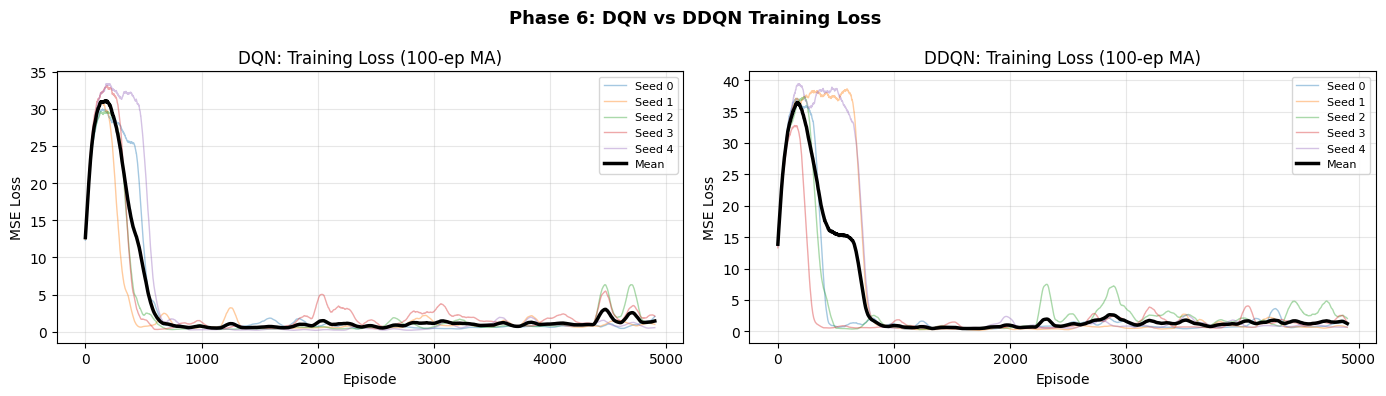

Saved: phase6_loss_detail.png


In [28]:
from src.plotting import moving_average as _ma

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for col, method in enumerate(["DQN", "DDQN"]):
    ax = axes[col]
    loss_mat = results[method]["losses"]   # list of N_SEEDS loss arrays
    smoothed = [_ma(np.array(L), window=100) for L in loss_mat]
    min_len  = min(len(s) for s in smoothed)
    for s_idx, sm in enumerate(smoothed):
        ax.plot(sm[:min_len], alpha=0.4, lw=1, label=f"Seed {s_idx}")
    mean_sm = np.array([s[:min_len] for s in smoothed]).mean(axis=0)
    ax.plot(mean_sm, color="black", lw=2.5, label="Mean")
    ax.set_xlabel("Episode"); ax.set_ylabel("MSE Loss")
    ax.set_title(f"{method}: Training Loss (100-ep MA)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("Phase 6: DQN vs DDQN Training Loss", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("phase6_loss_detail.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase6_loss_detail.png")

## Conclusions

### 1. Final Performance

All three methods successfully solve the MountainCar task, but with clear differences
in reliability. Q-Learning (20×20) achieved a mean success rate of **86.4%** across
seeds (range 78–94%), while both DQN and DDQN reached **97–97.4%**, with markedly
lower variance across seeds (std ≈ 1–2%). The neural network methods are not only
more successful on average but also more consistent — the tabular agent's performance
depends heavily on which random seed it drew.

### 2. Convergence Speed

This is where the gap is most striking. DQN reached 50% SR at episode **500**, 80%
at **547**, and 95% at **610** on average. Q-Learning required **1290**, **1981**,
and **2880** episodes for the same thresholds — roughly **3.5–4.7× more experience**.
DDQN was slightly slower than DQN to converge (564 / 607 / 651), but both deep
methods are dramatically more sample-efficient than the tabular baseline.

The reason is generalisation. The Q-network learns a smooth value function over the
continuous state space and immediately transfers knowledge from visited states to
nearby unvisited ones. The tabular agent treats each of its 400 bins as independent —
a bin is only updated when it is literally visited, so coverage takes far more episodes.

### 3. Policy Quality: Action Distribution

The action distribution reveals a qualitative difference in what the methods actually
learned. Q-Learning wastes **20.4%** of its greedy actions on no-ops (no push). DQN
reduces this to **8.8%**, and DDQN to just **2.8%**. All three methods correctly
favour rightward pushes (≈ 45–52%) and leftward pushes (≈ 34–45%), reflecting the
swing-up strategy, but the deep methods have nearly eliminated idle actions. This
aligns with the phase portraits: DQN and DDQN produce tight, efficient spirals to the
goal; Q-Learning traces wider, slower loops that take more steps per episode.

### 4. DQN vs DDQN: Loss and Overestimation

The loss curves show an interesting result. Both methods exhibit a sharp spike in
training loss during the first 200–400 episodes as the agent transitions from random
exploration to structured behaviour. The DDQN spike is actually slightly *larger*
(peak ≈ 37–40 vs ≈ 31 for DQN), which is counterintuitive given that DDQN was
designed to reduce overestimation. Both stabilise to a similar steady-state loss
(≈ 1–2) after episode 600. In final performance, DDQN matches DQN rather than
clearly surpassing it. This is consistent with the literature: DDQN's advantage is
most pronounced in environments with large, deterministic reward signals where
Q-value overestimation compounds significantly (e.g. Atari). In the relatively
low-variance MountainCar setting, the bias introduced by standard DQN is small
enough that both methods converge to the same quality.

### 5. Tabular vs Neural: When Does the Network Help?

On MountainCar-v0 the neural network's main advantage is **speed**, not ceiling
performance — the tabular agent does eventually converge to >80% SR, just slowly.
In a higher-dimensional environment (more state variables, larger action space) the
tabular approach would become infeasible, while the network would continue to scale.
The 20×20 grid is already quite dense for a 2D state space, so the marginal gain
from generalisation is moderate. The result illustrates the fundamental trade-off:
tabular methods are simpler and guaranteed to converge under standard conditions,
while function approximation trades those guarantees for scalability and, in this
case, substantially faster learning.

In [30]:
print("\n" + "="*60)
print("PHASE 6 COMPLETE")
print("="*60)
print("Saved: phase6_learning_curves.png")
print("       phase6_seed_variance.png")
print("       phase6_qvalue_landscapes.png")
print("       phase6_trajectories.png")
print("       phase6_action_dist.png")
print("       phase6_convergence.png")
print("       phase6_loss_detail.png")


PHASE 6 COMPLETE
Saved: phase6_learning_curves.png
       phase6_seed_variance.png
       phase6_qvalue_landscapes.png
       phase6_trajectories.png
       phase6_action_dist.png
       phase6_convergence.png
       phase6_loss_detail.png
